In [1]:
import torch
from src.data.puzzle_dataset import PuzzleDataset
from src.data.criterion.nonogram import NonogramLoss
from src.models.simple_nn import SimpleNeuralNetwork
from src.models.simple_transformer import SimpleTransformer
from src.training.reward_trainer import RewardTrainer
from src.training.gradient_analyser import GradientAnalyser
from src.data.criterion.nonogram import grid_to_row_clues
import matplotlib.pyplot as plt
import os

if "_NOTEBOOK_PARENT_DIR" not in globals():
    _NOTEBOOK_PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(_NOTEBOOK_PARENT_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset_name = "nonogram_5x5"

In [2]:
match dataset_name:
    case "nonogram_5x5":
        target_shape = (5, 5)
        location = "processed/nonogram_single_sample_5x5.npy"
    case "nonogram_15x15":
        target_shape = (15, 15)
        location = "processed/nonogram_single_sample_15x15.npy"


dataset = PuzzleDataset(
    location, 
    flat=True, 
    target_shape=target_shape)


In [3]:
dataset = PuzzleDataset(
    "processed/nonogram_single_sample_15x15.npy", 
    flat=True, 
    target_shape=(15, 15))

model = SimpleNeuralNetwork(
    hidden_size=128, 
    num_layers=6, 
    dropout=0.3, 
    input_size=dataset.input_shape, 
    output_size=dataset.target_shape).to(device)

criterion = NonogramLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [4]:
# import numpy as np
# n = np.load("data/processed/nonogram_single_sample.npy")
# print(n.shape)

In [5]:
# # n = torch.tensor([[
# #     [[2,1,0], [2,1,0], [4,0,0], [0,0,0], [1,0,0]], 
# #     [[1,0,0], [3,1,0], [1,1,0], [2,0,0], [1,1,0]]]], dtype=torch.float32)
# import numpy as np
# n = torch.tensor([
#     # Row clues (15 rows)
#     [
#         [2, 7, 0, 0, 0, 0, 0, 0],
#         [9, 0, 0, 0, 0, 0, 0, 0],
#         [8, 0, 0, 0, 0, 0, 0, 0],
#         [1, 1, 1, 1, 1, 0, 0, 0],
#         [3, 3, 0, 0, 0, 0, 0, 0],
#         [1, 2, 2, 0, 0, 0, 0, 0],
#         [2, 3, 3, 0, 0, 0, 0, 0],
#         [2, 3, 0, 0, 0, 0, 0, 0],
#         [3, 0, 0, 0, 0, 0, 0, 0],
#         [1, 3, 0, 0, 0, 0, 0, 0],
#         [2, 1, 3, 4, 0, 0, 0, 0],
#         [2, 9, 0, 0, 0, 0, 0, 0],
#         [2, 9, 0, 0, 0, 0, 0, 0],
#         [7, 1, 1, 0, 0, 0, 0, 0],
#         [5, 5, 0, 0, 0, 0, 0, 0]
#     ],
#     # Column clues (15 columns)
#     [
#         [3, 2, 5, 0, 0, 0, 0, 0],
#         [4, 1, 5, 0, 0, 0, 0, 0],
#         [2, 2, 0, 0, 0, 0, 0, 0],
#         [4, 2, 2, 0, 0, 0, 0, 0],
#         [3, 2, 0, 0, 0, 0, 0, 0],
#         [5, 1, 4, 0, 0, 0, 0, 0],
#         [3, 3, 4, 0, 0, 0, 0, 0],
#         [8, 3, 0, 0, 0, 0, 0, 0],
#         [2, 1, 3, 0, 0, 0, 0, 0],
#         [1, 2, 0, 0, 0, 0, 0, 0],
#         [4, 0, 0, 0, 0, 0, 0, 0],
#         [3, 1, 0, 0, 0, 0, 0, 0],
#         [1, 7, 1, 0, 0, 0, 0, 0],
#         [9, 1, 0, 0, 0, 0, 0, 0],
#         [8, 1, 0, 0, 0, 0, 0, 0]
#     ]
# ], dtype=torch.float32)
# repeated = n.repeat(128, 1, 1, 1)
# print(repeated.shape)
# print(repeated[0])
# np.save("data/processed/nonogram_single_sample_15x15.npy", repeated.cpu().numpy())


In [6]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, 
    [train_size, test_size],
    generator=generator
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=8, 
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=8, 
    shuffle=False
)

In [7]:
gradient_analyser = GradientAnalyser(model, criterion)
sample_inputs = next(iter(train_loader))
gradient_analyser.run_full_report(sample_inputs)


════════════════════════════════════════════════════════════════════════
  Criterion Gradient Probe  (dummy grid, all logits = 0.0)
════════════════════════════════════════════════════════════════════════
    tau       ‖∇grid‖        max|∇|    zero%  Status
────────────────────────────────────────────────────────────────────────
   0.10    0.0000e+00    0.0000e+00   100.0%  ⚠  VANISHING — loss won't train model at this tau
   0.30    0.0000e+00    0.0000e+00   100.0%  ⚠  VANISHING — loss won't train model at this tau
   0.50    0.0000e+00    0.0000e+00   100.0%  ⚠  VANISHING — loss won't train model at this tau
   1.00    0.0000e+00    0.0000e+00   100.0%  ⚠  VANISHING — loss won't train model at this tau
────────────────────────────────────────────────────────────────────────
  Grid shape: 8 × 10×10
════════════════════════════════════════════════════════════════════════


════════════════════════════════════════════════════════════════════════
  Layer-wise Gradient Norm Summary
════

In [8]:
trainer = RewardTrainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    scheduler=scheduler,
    epochs=100
)

gradient_analyser.register_hooks()
trainer.train()
gradient_analyser.remove_hooks()

🚀 Starting training...
Load: 0.005s | Transfer: 0.002s | Total: 0.241s
Epoch 00 | Train loss: 2.7755 | Test loss: 1.4161 | Test accuracy: 0.000% | Clue‑match: 0.10%
Load: 0.003s | Transfer: 0.001s | Total: 0.143s
Epoch 01 | Train loss: 1.3994 | Test loss: 1.3166 | Test accuracy: 0.000% | Clue‑match: 0.07%
Load: 0.003s | Transfer: 0.001s | Total: 0.139s
Epoch 02 | Train loss: 1.3204 | Test loss: 1.3333 | Test accuracy: 0.000% | Clue‑match: 0.07%
Load: 0.003s | Transfer: 0.002s | Total: 0.164s
Epoch 03 | Train loss: 1.3319 | Test loss: 1.3330 | Test accuracy: 0.000% | Clue‑match: 0.07%
Load: 0.002s | Transfer: 0.001s | Total: 0.131s
Epoch 04 | Train loss: 1.3457 | Test loss: 1.3167 | Test accuracy: 0.000% | Clue‑match: 0.07%
Load: 0.002s | Transfer: 0.001s | Total: 0.132s
Epoch 05 | Train loss: 1.3194 | Test loss: 1.3148 | Test accuracy: 0.000% | Clue‑match: 0.07%
Load: 0.002s | Transfer: 0.001s | Total: 0.133s
Epoch 06 | Train loss: 1.3165 | Test loss: 1.3167 | Test accuracy: 0.000% | C

In [9]:
gradient_analyser.print_summary()


════════════════════════════════════════════════════════════════════════
  Layer-wise Gradient Norm Summary
════════════════════════════════════════════════════════════════════════
Parameter                                   Mean       Std  Dead%  Magnitude (log scale)
────────────────────────────────────────────────────────────────────────
fc2.bias                                7.70e-04  6.52e-03  28.6%  [██░░░░░░░░░░░░░░░░] ⚠ VANISHING
fc2.weight                              2.09e-01  8.84e-01  17.9%  [██████████████████]
layers.4.bias                           3.50e-04  2.71e-03  30.6%  [░░░░░░░░░░░░░░░░░░] ⚠ VANISHING
layers.4.weight                         5.02e-02  2.44e-01  19.5%  [██████████████░░░░]
layers.3.bias                           4.29e-04  3.25e-03  30.0%  [█░░░░░░░░░░░░░░░░░] ⚠ VANISHING
layers.3.weight                         3.54e-02  1.91e-01  20.0%  [█████████████░░░░░]
layers.2.bias                           5.36e-04  4.08e-03  29.2%  [█░░░░░░░░░░░░░░░░░] ⚠ VA

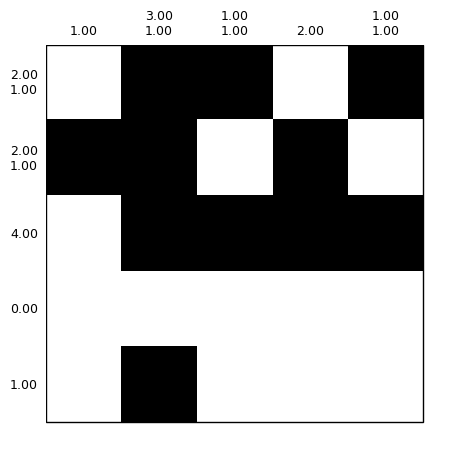

In [10]:
def visualise_matrix(matrix):
    inv_matrix = 1 - matrix
    fig, ax = plt.subplots()
    ax.imshow(inv_matrix.cpu().numpy(), cmap='gray')

    # Compute clues
    grid = matrix.reshape(1, *matrix.shape)
    row_clues = grid_to_row_clues(grid, K=3)
    col_clues = grid_to_row_clues(grid.transpose(1, 2), K=3)

    n_rows, n_cols = matrix.shape

    # Row clues on the left
    for r in range(n_rows):
        clue = row_clues[0, r].cpu().tolist()
        clue_str = "\n".join(f"{num:.2f}" for num in clue if num > 0) or "0.00"
        ax.text(-0.6, r, clue_str, va='center', ha='right', fontsize=9)

    # Column clues on the top
    for c in range(n_cols):
        clue = col_clues[0, c].cpu().tolist()
        clue_str = "\n".join(f"{num:.2f}" for num in clue if num > 0) or "0.00"
        ax.text(c, -0.6, clue_str, va='bottom', ha='center', fontsize=9)

    ax.set_xlim(-0.5, n_cols)
    ax.set_ylim(n_rows, -0.5)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)
    grid_box = plt.Rectangle((-0.5, -0.5), n_cols, n_rows,
                             linewidth=1, edgecolor='black', facecolor='none')
    ax.add_patch(grid_box)

    plt.tight_layout()
    plt.show()

visualise_matrix(torch.tensor(
    [[0, 1, 1, 0, 1],
    [1, 1, 0, 1, 0],
    [0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0]], dtype=torch.float32))

In [11]:
def visualise_guess(model, clues):
    model.eval()
    with torch.no_grad():
        output = model(clues)
        loss, _, _ = criterion(output, clues)
        visualise_matrix(output.reshape(5, 5))
        print(f"Loss: {loss.item():.4f}")
    model.train()

In [12]:
# dataset = PuzzleDataset(
#     "processed/nonogram_single_sample.npy", 
#     flat=True, 
#     target_shape=(5, 5))
dataset = PuzzleDataset(
    "processed/nonogram_single_sample_15x15.npy", 
    flat=True, 
    target_shape=(15, 15))

model = SimpleNeuralNetwork(
    hidden_size=128, 
    num_layers=6, 
    dropout=0.3, 
    input_size=dataset.input_shape, 
    output_size=dataset.target_shape).to(device)

criterion = NonogramLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

trainer = RewardTrainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    scheduler=scheduler,
    epochs=20
)

example_clues = torch.tensor([[
    [[2,1,0], [2,1,0], [4,0,0], [0,0,0], [1,0,0]], 
    [[1,0,0], [3,1,0], [1,1,0], [2,0,0], [1,1,0]]]], dtype=torch.float32).to(device)
example_clues = example_clues.flatten(start_dim=1)
visualise_guess(model, example_clues)
gradient_analyser.register_hooks()
trainer.train()
gradient_analyser.remove_hooks()
visualise_guess(model, example_clues)
# for i in range(10):
#     model.train()
#     trainer.train()
#     print("="*40)
#     print(f"Epoch {i+1}:")
#     visualise_guess(model, example_clues)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x30 and 240x128)

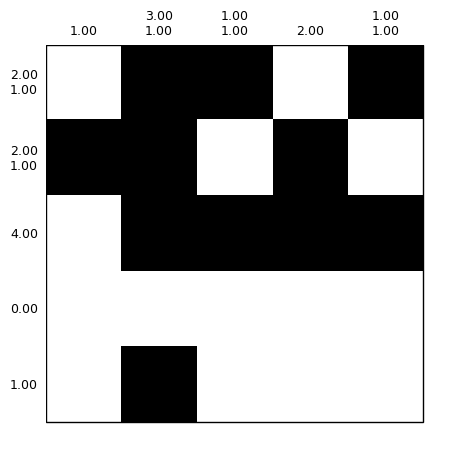

In [ ]:
def visualise_matrix(matrix):
    inv_matrix = 1 - matrix
    fig, ax = plt.subplots()
    ax.imshow(inv_matrix.cpu().numpy(), cmap='gray')

    # Compute clues
    grid = matrix.reshape(1, *matrix.shape)
    row_clues = grid_to_row_clues(grid, K=3)
    col_clues = grid_to_row_clues(grid.transpose(1, 2), K=3)

    n_rows, n_cols = matrix.shape

    # Row clues on the left
    for r in range(n_rows):
        clue = row_clues[0, r].cpu().tolist()
        clue_str = "\n".join(f"{num:.2f}" for num in clue if num > 0) or "0.00"
        ax.text(-0.6, r, clue_str, va='center', ha='right', fontsize=9)

    # Column clues on the top
    for c in range(n_cols):
        clue = col_clues[0, c].cpu().tolist()
        clue_str = "\n".join(f"{num:.2f}" for num in clue if num > 0) or "0.00"
        ax.text(c, -0.6, clue_str, va='bottom', ha='center', fontsize=9)

    ax.set_xlim(-0.5, n_cols)
    ax.set_ylim(n_rows, -0.5)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)
    grid_box = plt.Rectangle((-0.5, -0.5), n_cols, n_rows,
                             linewidth=1, edgecolor='black', facecolor='none')
    ax.add_patch(grid_box)

    plt.tight_layout()
    plt.show()

visualise_matrix(torch.tensor(
    [[0, 1, 1, 0, 1],
    [1, 1, 0, 1, 0],
    [0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0]], dtype=torch.float32))

def visualise_guess(model, clues, shape=(5, 5)):
    model.eval()
    with torch.no_grad():
        output = model(clues)
        loss, _, _ = criterion(output, clues)
        visualise_matrix(output.reshape(*shape))
        print(f"Loss: {loss.item():.4f}")
    model.train()


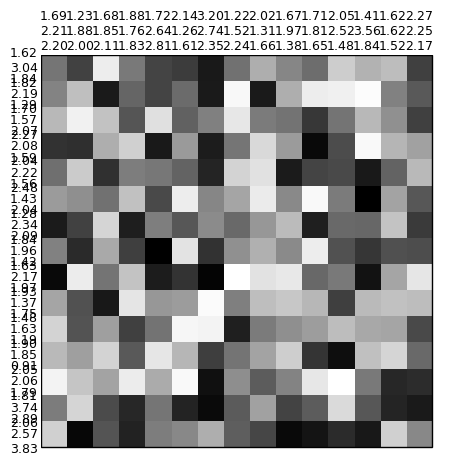

Loss: 5.4173
🚀 Starting training...
Load: 0.006s | Transfer: 0.011s | Total: -0.767s
Epoch 00 | Train loss: 4.3110 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.006s | Transfer: 0.007s | Total: 0.205s
Epoch 00 | Train loss: 3.9335 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.012s | Transfer: 0.005s | Total: 0.281s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.103s
Epoch 00 | Train loss: 3.9329 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.107s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.107s
Epoch 00 | Train loss: 3.9329 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.

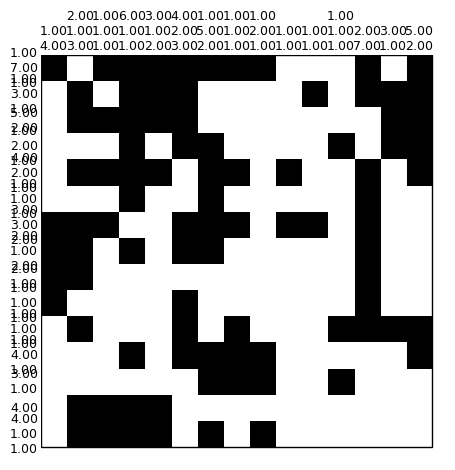

Loss: 3.9333
🚀 Starting training...
Load: 0.008s | Transfer: 0.004s | Total: 0.194s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.007s | Transfer: 0.003s | Total: 0.175s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.007s | Transfer: 0.003s | Total: 0.145s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.006s | Transfer: 0.003s | Total: 0.164s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.004s | Transfer: 0.002s | Total: 0.096s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.002s | Transfer: 0.002s | Total: 0.084s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.0

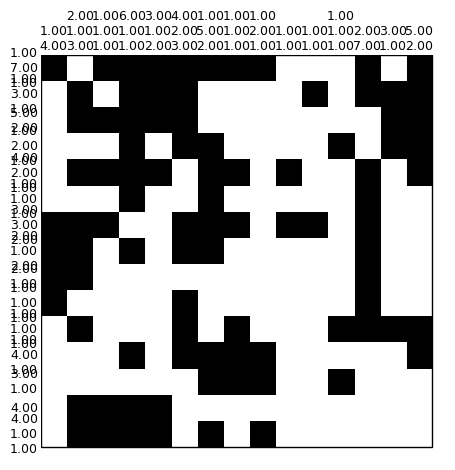

Loss: 3.9333
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.098s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.003s | Transfer: 0.003s | Total: 0.112s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.004s | Transfer: 0.002s | Total: 0.104s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.004s | Transfer: 0.002s | Total: 0.113s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.105s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.003s | Transfer: 0.001s | Total: 0.079s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.0

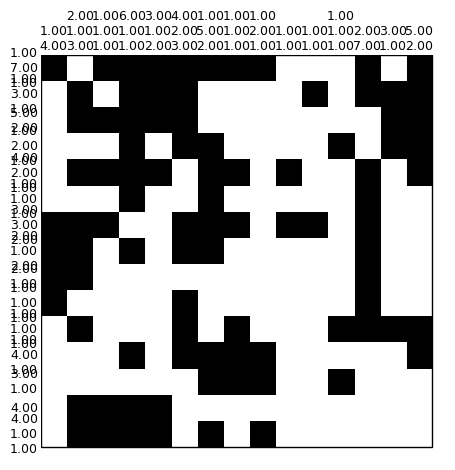

Loss: 3.9333
🚀 Starting training...
Load: 0.004s | Transfer: 0.002s | Total: 0.120s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.131s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.004s | Transfer: 0.002s | Total: 0.161s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.105s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.004s | Transfer: 0.002s | Total: 0.136s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.004s | Transfer: 0.002s | Total: 0.139s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.0

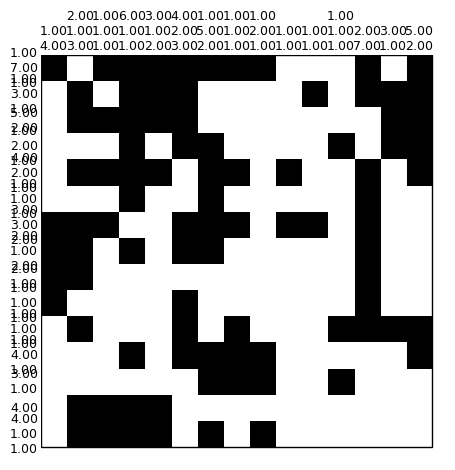

Loss: 3.9333
🚀 Starting training...
Load: 0.004s | Transfer: 0.002s | Total: 0.135s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.002s | Transfer: 0.001s | Total: 0.080s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.085s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.002s | Transfer: 0.002s | Total: 0.073s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.002s | Transfer: 0.002s | Total: 0.082s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.00%
🚀 Starting training...
Load: 0.002s | Transfer: 0.001s | Total: 0.080s
Epoch 00 | Train loss: 3.9333 | Test loss: 3.9333 | Test accuracy: 0.000% | Clue‑match: 0.0

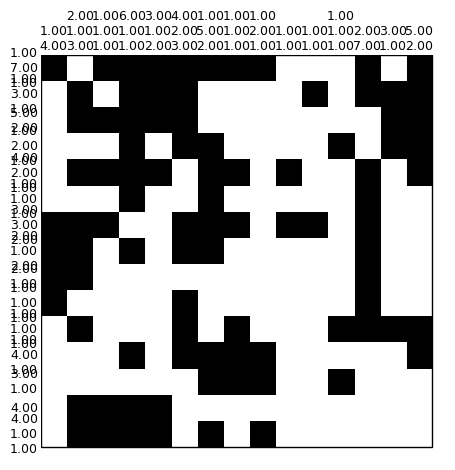

Loss: 3.9333


In [ ]:
dataset = PuzzleDataset(
    "processed/nonogram_single_sample_15x15.npy", 
    flat=True, 
    target_shape=(15, 15))

model = SimpleNeuralNetwork(
    hidden_size=128, 
    num_layers=6, 
    dropout=0.05, 
    input_size=dataset.input_shape, 
    output_size=dataset.target_shape).to(device)

# model = SimpleTransformer(
#     hidden_size=128,
#     num_layers=3,
#     dropout=0.3,
#     input_size=dataset.input_shape,
#     output_size=dataset.target_shape).to(device)

criterion = NonogramLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

trainer = RewardTrainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    scheduler=scheduler,
    epochs=1
)
torch.manual_seed(42)

# example_clues = torch.tensor([[[[2,1,0], [2,1,0], [4,0,0], [0,0,0], [1,0,0]], [[1,0,0], [3,1,0], [1,1,0], [2,0,0], [1,1,0]]]], dtype=torch.float32).to(device)
example_clues = torch.tensor([[
    # Row clues (15 rows)
    [
        [2, 7, 0, 0, 0, 0, 0, 0],
        [9, 0, 0, 0, 0, 0, 0, 0],
        [8, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [3, 3, 0, 0, 0, 0, 0, 0],
        [1, 2, 2, 0, 0, 0, 0, 0],
        [2, 3, 3, 0, 0, 0, 0, 0],
        [2, 3, 0, 0, 0, 0, 0, 0],
        [3, 0, 0, 0, 0, 0, 0, 0],
        [1, 3, 0, 0, 0, 0, 0, 0],
        [2, 1, 3, 4, 0, 0, 0, 0],
        [2, 9, 0, 0, 0, 0, 0, 0],
        [2, 9, 0, 0, 0, 0, 0, 0],
        [7, 1, 1, 0, 0, 0, 0, 0],
        [5, 5, 0, 0, 0, 0, 0, 0]
    ],
    # Column clues (15 columns)
    [
        [3, 2, 5, 0, 0, 0, 0, 0],
        [4, 1, 5, 0, 0, 0, 0, 0],
        [2, 2, 0, 0, 0, 0, 0, 0],
        [4, 2, 2, 0, 0, 0, 0, 0],
        [3, 2, 0, 0, 0, 0, 0, 0],
        [5, 1, 4, 0, 0, 0, 0, 0],
        [3, 3, 4, 0, 0, 0, 0, 0],
        [8, 3, 0, 0, 0, 0, 0, 0],
        [2, 1, 3, 0, 0, 0, 0, 0],
        [1, 2, 0, 0, 0, 0, 0, 0],
        [4, 0, 0, 0, 0, 0, 0, 0],
        [3, 1, 0, 0, 0, 0, 0, 0],
        [1, 7, 1, 0, 0, 0, 0, 0],
        [9, 1, 0, 0, 0, 0, 0, 0],
        [8, 1, 0, 0, 0, 0, 0, 0]
    ]]], dtype=torch.float32).to(device)
example_clues = example_clues.flatten(start_dim=1)
visualise_guess(model, example_clues, shape=(15, 15))
for i in range(50):
    trainer.train()
    if (i+1) % 10 == 0:
        print("="*40)
        print(f"Epoch {i+1}:")
        visualise_guess(model, example_clues, shape=(15, 15))

In [ ]:
pred = model(example_clues)
pred_2dp = torch.round(pred * 100) / 100
shape = (15, 15)

print(pred_2dp.reshape(*shape))
print(torch.round(grid_to_row_clues(pred_2dp.reshape(*shape), K=8) * 100) / 100)
print(torch.round(grid_to_row_clues(pred_2dp.transpose(0, 1).reshape(*shape), K=8) * 100) / 100)
print(example_clues.reshape(2, 15, 8))
print(trainer._run_length_match(pred_2dp, example_clues))

tensor([[0.9800, 1.0000, 0.0200, 1.0000, 1.0000, 1.0000, 0.9900, 1.0000, 0.9900,
         0.5100, 1.0000, 0.0000, 0.0200, 1.0000, 1.0000],
        [0.7400, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.8800,
         0.4500, 1.0000, 0.0000, 0.0000, 1.0000, 1.0000],
        [0.8900, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.0100,
         0.0000, 0.5800, 0.0000, 0.0000, 1.0000, 1.0000],
        [0.3800, 0.7000, 0.0000, 0.4900, 0.0000, 0.9200, 0.1600, 1.0000, 0.0000,
         0.0000, 0.4500, 0.0000, 0.9600, 1.0000, 1.0000],
        [0.3600, 0.0500, 0.0000, 0.7000, 1.0000, 1.0000, 0.9900, 1.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0400, 1.0000, 1.0000],
        [0.2200, 0.0500, 0.0000, 0.0000, 0.4600, 0.0000, 0.8400, 1.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 1.0000, 1.0000, 1.0000],
        [0.0100, 0.0000, 0.9800, 1.0000, 0.0700, 0.0000, 0.9900, 1.0000, 0.4500,
         0.0000, 0.0500, 0.2900, 1.0000, 1.0000, 1.0000],
        [0.0100, 0.0000, 0.

In [ ]:
print(dataset[0])

tensor([2., 1., 0., 2., 1., 0., 4., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0.,
        3., 1., 0., 1., 1., 0., 2., 0., 0., 1., 1., 0.])


In [ ]:
class NonogramTransformer(nn.Module):
    """Transformer that treats each row/column clue as a separate token."""
    
    def __init__(self, vocab_size=16, hidden_size=128, num_layers=3, 
                 num_heads=4, dropout=0.3, output_size=(15, 15)):
        super().__init__()
        self.output_size = output_size
        self.out_dim = output_size[0] * output_size[1]
        
        # Embed each number in a clue (0-15, plus padding)
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        
        # Position encoding for sequence position within a clue
        self.pos_encoding = nn.Parameter(torch.randn(1, 8, hidden_size) * 0.02)
        
        # Type encoding: row clue vs column clue
        self.type_encoding = nn.Parameter(torch.randn(1, 2, hidden_size) * 0.02)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output head
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, self.out_dim)
        )
    
    def forward(self, x):
        # x shape: (B, 30, 8) — 30 clues (15 rows + 15 cols), each up to 8 numbers
        B = x.size(0)
        
        # Embed the numbers
        x = self.embedding(x)  # (B, 30, 8, hidden_size)
        
        # Mean pool each clue to get one vector per clue
        x = x.mean(dim=2)  # (B, 30, hidden_size)
        
        # Add type encoding (first 15 = rows, last 15 = cols)
        x[:, :15, :] += self.type_encoding[:, 0:1, :]
        x[:, 15:, :] += self.type_encoding[:, 1:2, :]
        
        # Pass through transformer
        x = self.transformer(x)  # (B, 30, hidden_size)
        
        # Use mean of all clue representations
        x = x.mean(dim=1)  # (B, hidden_size)
        
        logits = self.head(x)  # (B, 225)
        return logits.view(B, *self.output_size)

In [ ]:
from torch import nn
class NonogramTransformer(nn.Module):
    """Transformer that treats each row/column clue as a separate token."""
    
    def __init__(self, vocab_size=16, hidden_size=128, num_layers=3, 
                 num_heads=4, dropout=0.3, output_size=(15, 15)):
        super().__init__()
        self.output_size = output_size
        self.out_dim = output_size[0] * output_size[1]
        
        # Embed each number in a clue (0-15, plus padding)
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        
        # Position encoding for sequence position within a clue
        self.pos_encoding = nn.Parameter(torch.randn(1, 8, hidden_size) * 0.02)
        
        # Type encoding: row clue vs column clue
        self.type_encoding = nn.Parameter(torch.randn(1, 2, hidden_size) * 0.02)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output head
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, self.out_dim)
        )
    
    def forward(self, x):
        # x shape: (B, 30, 8) — 30 clues (15 rows + 15 cols), each up to 8 numbers
        B = x.size(0)
        
        # Embed the numbers
        x = self.embedding(x)  # (B, 30, 8, hidden_size)
        
        # Mean pool each clue to get one vector per clue
        x = x.mean(dim=2)  # (B, 30, hidden_size)
        
        # Add type encoding (first 15 = rows, last 15 = cols)
        x[:, :15, :] += self.type_encoding[:, 0:1, :]
        x[:, 15:, :] += self.type_encoding[:, 1:2, :]
        
        # Pass through transformer
        x = self.transformer(x)  # (B, 30, hidden_size)
        
        # Use mean of all clue representations
        x = x.mean(dim=1)  # (B, hidden_size)
        
        logits = self.head(x)  # (B, 225)
        return logits.view(B, *self.output_size)

In [ ]:
dataset = PuzzleDataset(
    "processed/nonogram_single_sample_15x15.npy", 
    flat=True, 
    target_shape=(15, 15))

model = NonogramTransformer(
    vocab_size=16,
    hidden_size=128,
    num_layers=3,
    num_heads=4,
    dropout=0.3,
    output_size=(15, 15)
).to(device)

criterion = NonogramLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

trainer = RewardTrainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    scheduler=scheduler,
    epochs=1
)
torch.manual_seed(42)

# example_clues = torch.tensor([[[[2,1,0], [2,1,0], [4,0,0], [0,0,0], [1,0,0]], [[1,0,0], [3,1,0], [1,1,0], [2,0,0], [1,1,0]]]], dtype=torch.float32).to(device)
example_clues = torch.tensor([[
    # Row clues (15 rows)
    [
        [2, 7, 0, 0, 0, 0, 0, 0],
        [9, 0, 0, 0, 0, 0, 0, 0],
        [8, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [3, 3, 0, 0, 0, 0, 0, 0],
        [1, 2, 2, 0, 0, 0, 0, 0],
        [2, 3, 3, 0, 0, 0, 0, 0],
        [2, 3, 0, 0, 0, 0, 0, 0],
        [3, 0, 0, 0, 0, 0, 0, 0],
        [1, 3, 0, 0, 0, 0, 0, 0],
        [2, 1, 3, 4, 0, 0, 0, 0],
        [2, 9, 0, 0, 0, 0, 0, 0],
        [2, 9, 0, 0, 0, 0, 0, 0],
        [7, 1, 1, 0, 0, 0, 0, 0],
        [5, 5, 0, 0, 0, 0, 0, 0]
    ],
    # Column clues (15 columns)
    [
        [3, 2, 5, 0, 0, 0, 0, 0],
        [4, 1, 5, 0, 0, 0, 0, 0],
        [2, 2, 0, 0, 0, 0, 0, 0],
        [4, 2, 2, 0, 0, 0, 0, 0],
        [3, 2, 0, 0, 0, 0, 0, 0],
        [5, 1, 4, 0, 0, 0, 0, 0],
        [3, 3, 4, 0, 0, 0, 0, 0],
        [8, 3, 0, 0, 0, 0, 0, 0],
        [2, 1, 3, 0, 0, 0, 0, 0],
        [1, 2, 0, 0, 0, 0, 0, 0],
        [4, 0, 0, 0, 0, 0, 0, 0],
        [3, 1, 0, 0, 0, 0, 0, 0],
        [1, 7, 1, 0, 0, 0, 0, 0],
        [9, 1, 0, 0, 0, 0, 0, 0],
        [8, 1, 0, 0, 0, 0, 0, 0]
    ]]], dtype=torch.float32).to(device)
example_clues = example_clues.flatten(start_dim=1)
visualise_guess(model, example_clues, shape=(15, 15))
for i in range(50):
    trainer.train()
    if (i+1) % 10 == 0:
        print("="*40)
        print(f"Epoch {i+1}:")
        visualise_guess(model, example_clues, shape=(15, 15))

RuntimeError: Expected tensor for argument #1 'indices' to have one of the following scalar types: Long, Int; but got torch.cuda.FloatTensor instead (while checking arguments for embedding)